# Task 1: Exploratory Data Analysis (EDA):

1.	Load the dataset and perform basic data exploration.

2.	Examine the distribution of features using histograms, box plots, or density plots.

3.	Investigate correlations between features to understand relationships within the data.

Task 2: Dimensionality Reduction with PCA:

1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.

2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.

3.	Transform the original dataset into the principal components.

Task 3: Clustering with Original Data:

1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.

2.	Visualize the clustering results using appropriate plots.

3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.

Task 4: Clustering with PCA Data:

1.	Apply the same clustering algorithm to the PCA-transformed dataset.

2.	Visualize the clustering results obtained from PCA-transformed data.

3.	Compare the clustering results from PCA-transformed data with those from the original dataset.

Task 5: Comparison and Analysis:

1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.

2.	Discuss any similarities or differences observed in the clustering results.

3.	Reflect on the impact of dimensionality reduction on clustering performance.

4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.

Task 6: Conclusion and Insights

1.	Summarize the key findings and insights from the assignment.

2.	Discuss the practical implications of using PCA and clustering in data analysis.

3.	Provide recommendations for when to use each technique based on the analysis conducted.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/wine.csv')
df

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [ ]:
df.shape

(178, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
# Display descriptive statistics
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [ ]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=np.number)

print("Numerical columns:")
print(numeric_df.columns.tolist())

print("\nShape of numerical data:", numeric_df.shape)

Numerical columns:
['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols', 'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue', 'Dilution', 'Proline']

Shape of numerical data: (178, 14)


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# Create an imputer
imputer = SimpleImputer(strategy="median")

# Apply median imputation
X_imputed = imputer.fit_transform(numeric_df)

# Convert back to DataFrame
X_imputed = pd.DataFrame(
    X_imputed,
    columns=numeric_df.columns,
    index=numeric_df.index
)

# Check missing values after imputation
print("Missing values after imputation:")
print(X_imputed.isnull().sum())

Missing values after imputation:
Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64


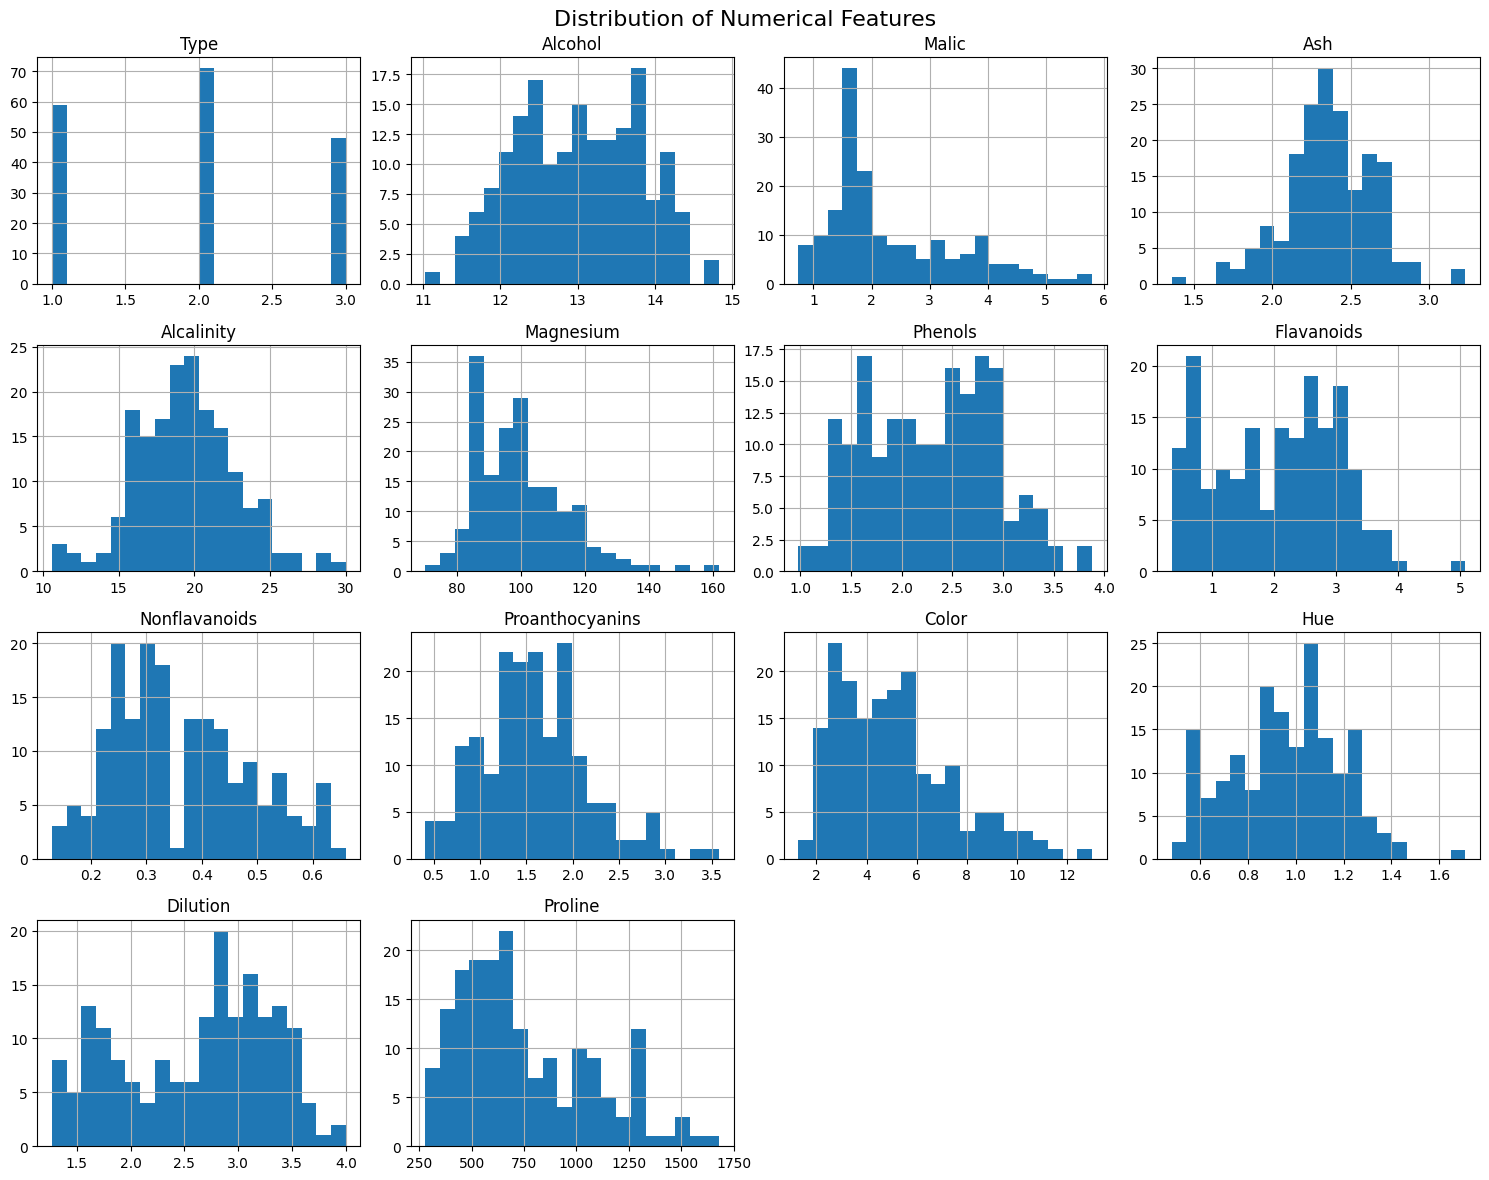

In [ ]:
# Plot histograms
X_imputed.hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

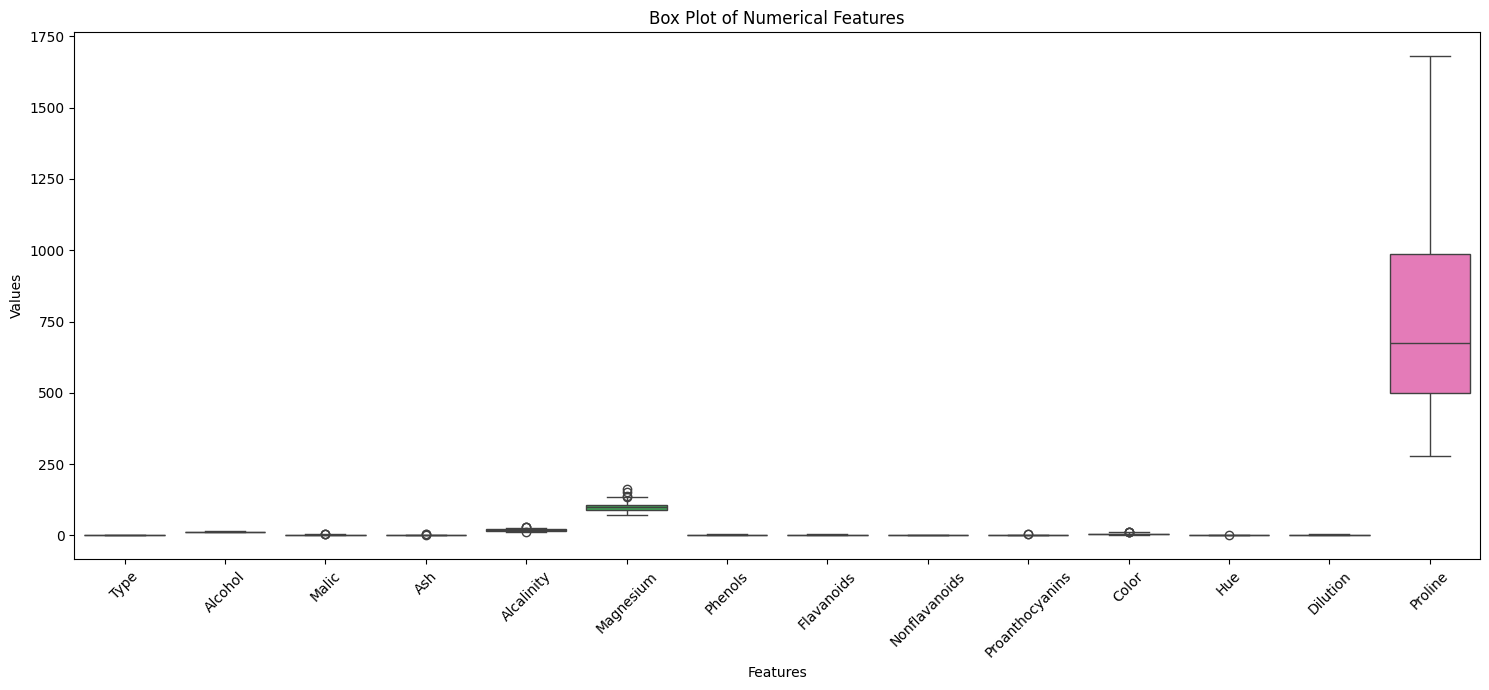

In [ ]:
# Create box plot
plt.figure(figsize=(15, 7))

sns.boxplot(data=X_imputed)

plt.title("Box Plot of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

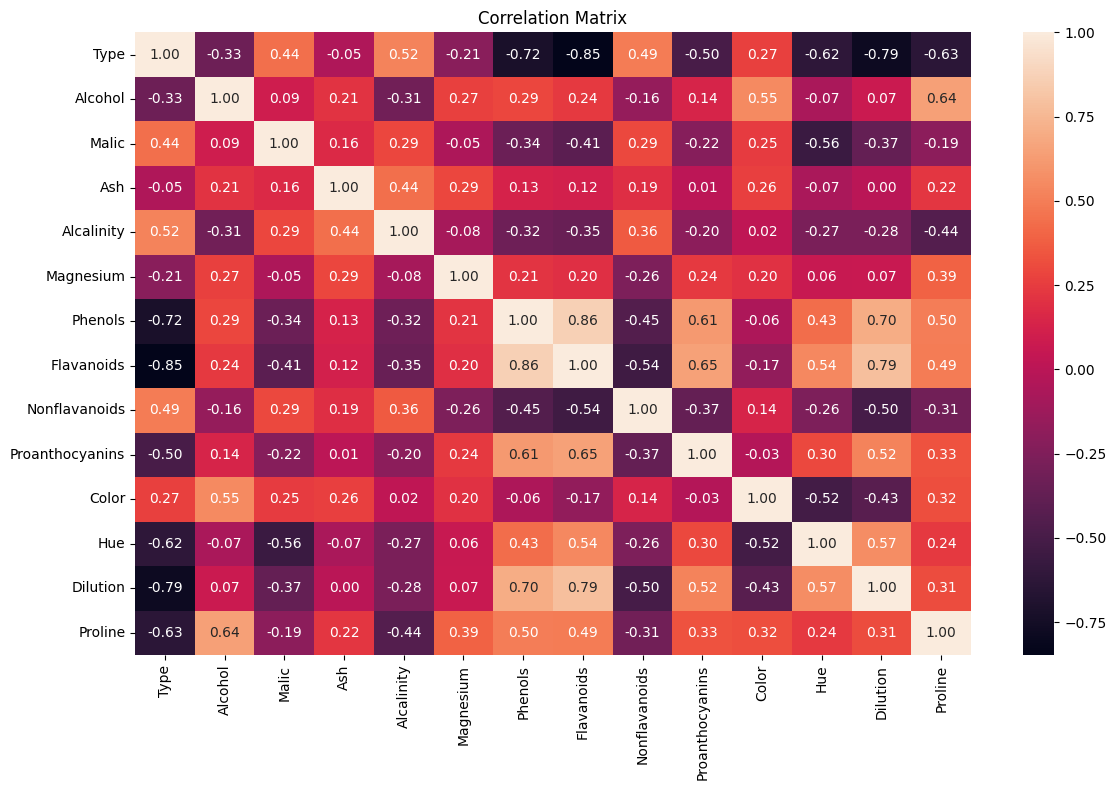

In [ ]:
# Calculate correlation matrix
correlation = X_imputed.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# Create StandardScaler
scaler = StandardScaler()

# Standardize the numerical data
X_scaled = scaler.fit_transform(X_imputed)

# Convert to DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X_imputed.columns
)

# Display standardized data
X_scaled_df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,-1.213944,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,-1.213944,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,-1.213944,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,-1.213944,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,-1.213944,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [ ]:
# Check mean and standard deviation
print("Mean of standardized features:")
print(X_scaled_df.mean().round(2))

print("\nStandard deviation:")
print(X_scaled_df.std().round(2))

Mean of standardized features:
Type               0.0
Alcohol           -0.0
Malic             -0.0
Ash               -0.0
Alcalinity        -0.0
Magnesium         -0.0
Phenols            0.0
Flavanoids        -0.0
Nonflavanoids      0.0
Proanthocyanins   -0.0
Color              0.0
Hue                0.0
Dilution           0.0
Proline           -0.0
dtype: float64

Standard deviation:
Type               1.0
Alcohol            1.0
Malic              1.0
Ash                1.0
Alcalinity         1.0
Magnesium          1.0
Phenols            1.0
Flavanoids         1.0
Nonflavanoids      1.0
Proanthocyanins    1.0
Color              1.0
Hue                1.0
Dilution           1.0
Proline            1.0
dtype: float64


In [ ]:
# Apply PCA without limiting the number of components
pca = PCA()

# Fit PCA and transform the standardized data
X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Number of PCA components:", X_pca.shape[1])

Original number of features: 14
Number of PCA components: 14


In [ ]:
# Display explained variance ratio
explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:")
print(explained_variance)

Explained variance ratio:
[0.39542486 0.17836259 0.10329102 0.06627984 0.06267875 0.0480556
 0.03955707 0.02500244 0.02103871 0.01873615 0.01613203 0.01205691
 0.00925458 0.00412945]


In [ ]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print("Cumulative explained variance:")
print(cumulative_variance)

Cumulative explained variance:
[0.39542486 0.57378745 0.67707846 0.74335831 0.80603706 0.85409266
 0.89364973 0.91865217 0.93969088 0.95842703 0.97455906 0.98661596
 0.99587055 1.        ]


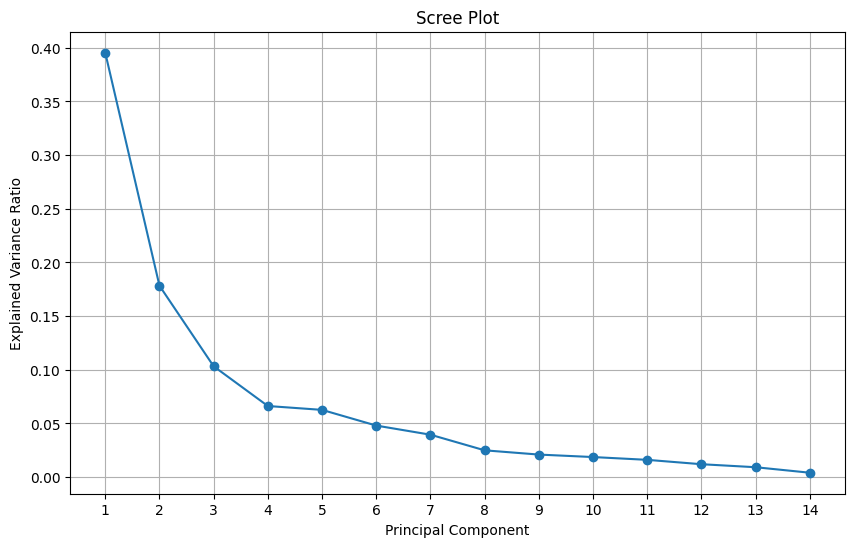

In [ ]:
# Create scree plot
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.xticks(
    range(1, len(explained_variance) + 1)
)

plt.grid(True)

plt.show()

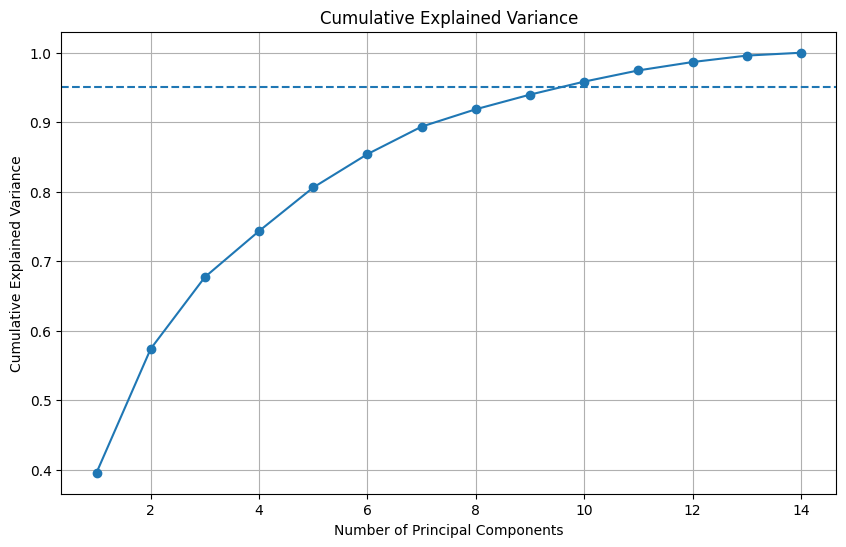

In [ ]:
# Plot cumulative explained variance
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

# 95% reference line
plt.axhline(
    y=0.95,
    linestyle="--"
)

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.grid(True)

plt.show()

In [ ]:
# Find number of components needed for 95% variance
n_components = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Number of components required for 95% variance:",
    n_components
)

Number of components required for 95% variance: 10


In [ ]:
# Apply PCA with the selected number of components
pca_final = PCA(
    n_components=n_components
)

# Transform standardized data
X_pca_final = pca_final.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA-transformed shape:", X_pca_final.shape)

Original shape: (178, 14)
PCA-transformed shape: (178, 10)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
# Store silhouette scores
silhouette_scores_original = []

# Test cluster numbers from 2 to 10
cluster_range = range(2, 11)

for k in cluster_range:

    # Create K-Means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit model
    labels = kmeans.fit_predict(X_scaled)

    # Calculate silhouette score
    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores_original.append(score)

# Display scores
for k, score in zip(
    cluster_range,
    silhouette_scores_original
):
    print(
        f"K = {k}, Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.2862
K = 3, Silhouette Score = 0.3077
K = 4, Silhouette Score = 0.2712
K = 5, Silhouette Score = 0.2517
K = 6, Silhouette Score = 0.2604
K = 7, Silhouette Score = 0.1428
K = 8, Silhouette Score = 0.2061
K = 9, Silhouette Score = 0.1326
K = 10, Silhouette Score = 0.1455


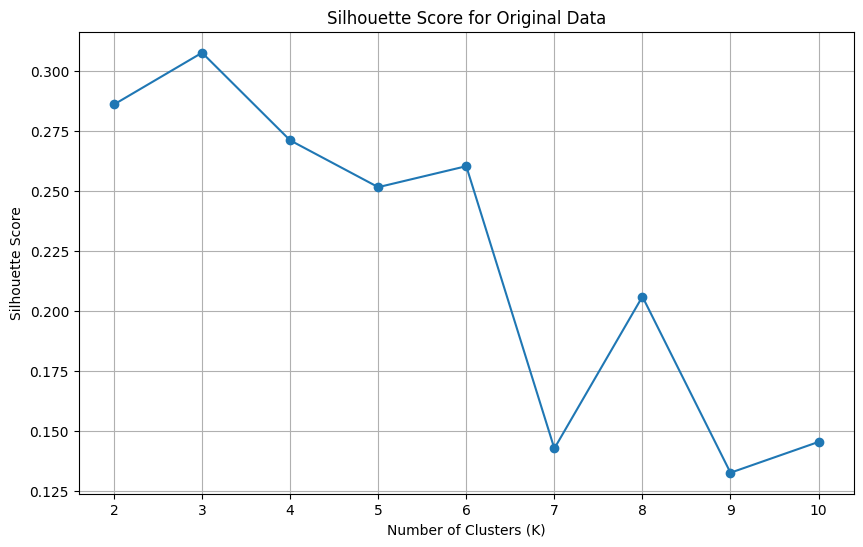

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(cluster_range),
    silhouette_scores_original,
    marker="o"
)

plt.title("Silhouette Score for Original Data")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(list(cluster_range))
plt.grid(True)

plt.show()

In [ ]:
# Select K with highest silhouette score
best_k_original = list(cluster_range)[
    np.argmax(silhouette_scores_original)
]

print(
    "Best number of clusters for original data:",
    best_k_original
)

Best number of clusters for original data: 3


In [ ]:
# Create final K-Means model
kmeans_original = KMeans(
    n_clusters=best_k_original,
    random_state=42,
    n_init=10
)

# Generate cluster labels
original_labels = kmeans_original.fit_predict(
    X_scaled
)

# Add cluster labels to a copy of the dataset
df_original_clustered = df.copy()

df_original_clustered["Cluster_Original"] = original_labels

# Display results
df_original_clustered.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Cluster_Original
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0


In [ ]:
# Calculate silhouette score
silhouette_original = silhouette_score(
    X_scaled,
    original_labels
)

print(
    "Original Data Silhouette Score:",
    round(silhouette_original, 4)
)

Original Data Silhouette Score: 0.3077


In [ ]:
# Calculate Davies-Bouldin Index
db_original = davies_bouldin_score(
    X_scaled,
    original_labels
)

print(
    "Original Data Davies-Bouldin Index:",
    round(db_original, 4)
)

Original Data Davies-Bouldin Index: 1.3164


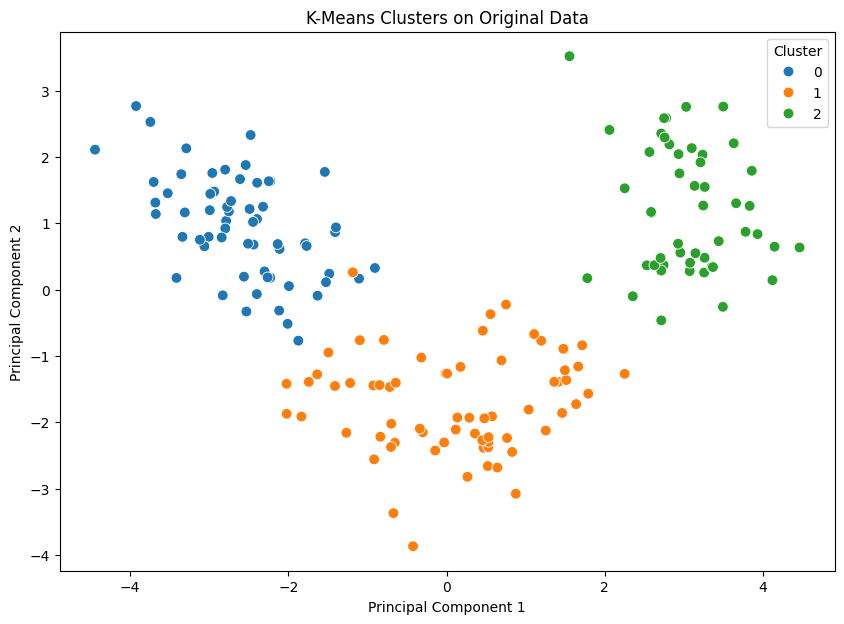

In [ ]:
# Create visualization using first two PCA components
visual_original = PCA(
    n_components=2
).fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=visual_original[:, 0],
    y=visual_original[:, 1],
    hue=original_labels,
    palette="tab10",
    s=60
)

plt.title("K-Means Clusters on Original Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

In [ ]:
# Store PCA silhouette scores
silhouette_scores_pca = []

# Test K values from 2 to 10
for k in cluster_range:

    # Create K-Means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit model on PCA data
    labels = kmeans.fit_predict(
        X_pca_final
    )

    # Calculate silhouette score
    score = silhouette_score(
        X_pca_final,
        labels
    )

    silhouette_scores_pca.append(score)

# Display scores
for k, score in zip(
    cluster_range,
    silhouette_scores_pca
):
    print(
        f"K = {k}, Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.2990
K = 3, Silhouette Score = 0.3241
K = 4, Silhouette Score = 0.2916
K = 5, Silhouette Score = 0.2705
K = 6, Silhouette Score = 0.2172
K = 7, Silhouette Score = 0.1560
K = 8, Silhouette Score = 0.1617
K = 9, Silhouette Score = 0.1526
K = 10, Silhouette Score = 0.1657


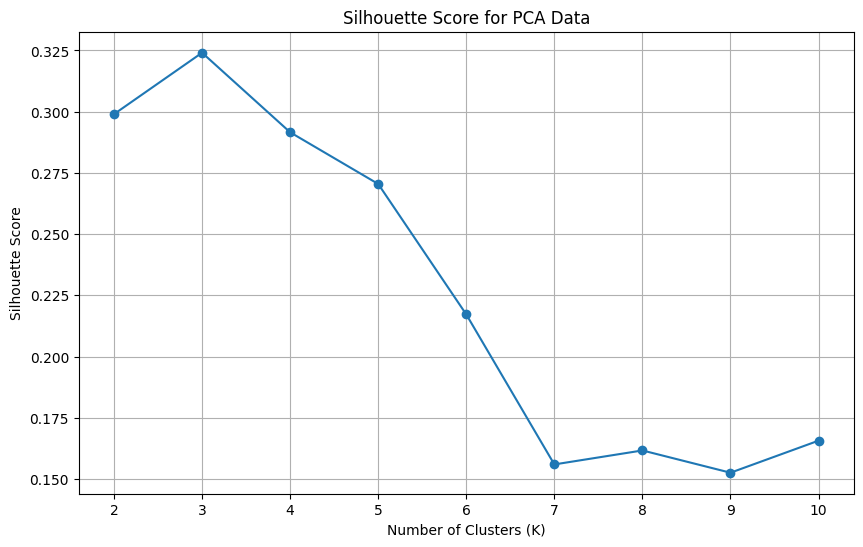

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(cluster_range),
    silhouette_scores_pca,
    marker="o"
)

plt.title("Silhouette Score for PCA Data")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(list(cluster_range))
plt.grid(True)

plt.show()

In [ ]:
# Select the K with highest silhouette score
best_k_pca = list(cluster_range)[
    np.argmax(silhouette_scores_pca)
]

print(
    "Best number of clusters for PCA data:",
    best_k_pca
)

Best number of clusters for PCA data: 3


In [ ]:
# Create final K-Means model for PCA data
kmeans_pca = KMeans(
    n_clusters=best_k_pca,
    random_state=42,
    n_init=10
)

# Generate cluster labels
pca_labels = kmeans_pca.fit_predict(
    X_pca_final
)

# Add PCA cluster labels
df_pca_clustered = df.copy()

df_pca_clustered["Cluster_PCA"] = pca_labels

# Display results
df_pca_clustered.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Cluster_PCA
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0


In [ ]:
# Calculate PCA silhouette score
silhouette_pca = silhouette_score(
    X_pca_final,
    pca_labels
)

print(
    "PCA Data Silhouette Score:",
    round(silhouette_pca, 4)
)

PCA Data Silhouette Score: 0.3241


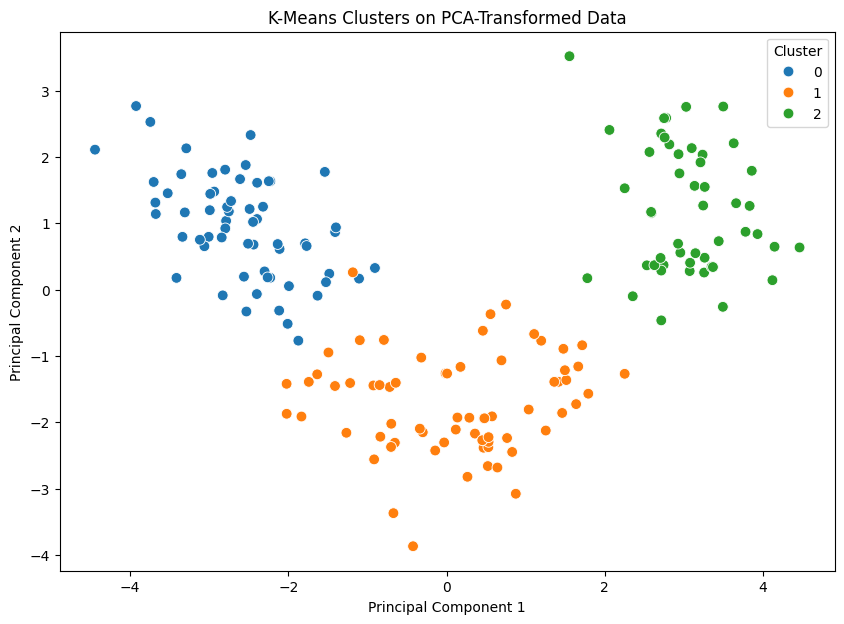

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca_final[:, 0],
    y=X_pca_final[:, 1],
    hue=pca_labels,
    palette="tab10",
    s=60
)

plt.title("K-Means Clusters on PCA-Transformed Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

In [ ]:
# Calculate PCA Davies-Bouldin Index
db_pca = davies_bouldin_score(
    X_pca_final,
    pca_labels
)

print(
    "PCA Data Davies-Bouldin Index:",
    round(db_pca, 4)
)

# Create comparison table
comparison = pd.DataFrame({
    "Method": [
        "Original Data",
        "PCA Data"
    ],
    "Number of Clusters": [
        best_k_original,
        best_k_pca
    ],
    "Silhouette Score": [
        silhouette_original,
        silhouette_pca
    ],
    "Davies-Bouldin Index": [
        db_original,
        db_pca
    ]
})

# Display comparison
comparison

PCA Data Davies-Bouldin Index: 1.2585


,Method,Number of Clusters,Silhouette Score,Davies-Bouldin Index
0,Original Data,3,0.307736,1.316396
1,PCA Data,3,0.324066,1.258489


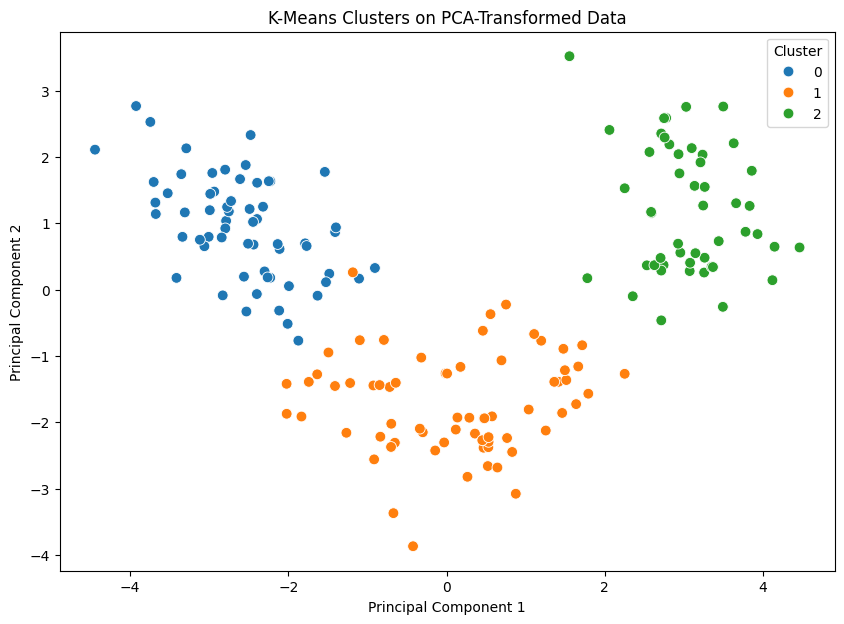

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca_final[:, 0],
    y=X_pca_final[:, 1],
    hue=pca_labels,
    palette="tab10",
    s=60
)

plt.title("K-Means Clusters on PCA-Transformed Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

In [ ]:
# Create comparison table
comparison = pd.DataFrame({
    "Method": [
        "Original Data",
        "PCA Data"
    ],
    "Number of Clusters": [
        best_k_original,
        best_k_pca
    ],
    "Silhouette Score": [
        silhouette_original,
        silhouette_pca
    ],
    "Davies-Bouldin Index": [
        db_original,
        db_pca
    ]
})

# Display comparison
comparison

,Method,Number of Clusters,Silhouette Score,Davies-Bouldin Index
0,Original Data,3,0.307736,1.316396
1,PCA Data,3,0.324066,1.258489


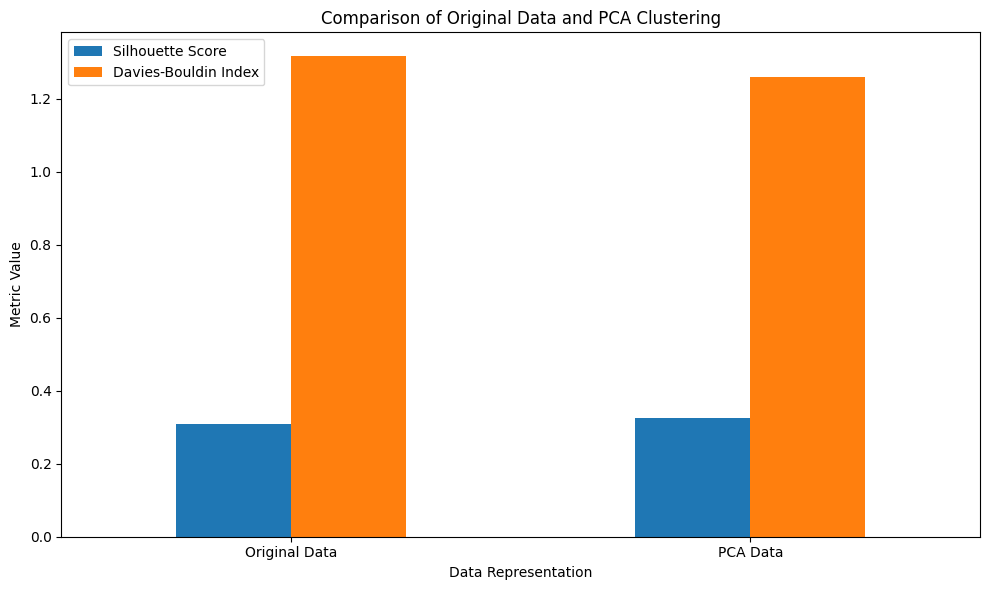

In [ ]:
# Create a DataFrame for plotting
comparison_metrics = comparison.set_index(
    "Method"
)[
    ["Silhouette Score", "Davies-Bouldin Index"]
]

# Plot comparison
comparison_metrics.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Comparison of Original Data and PCA Clustering"
)

plt.xlabel("Data Representation")
plt.ylabel("Metric Value")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Count observations in each original cluster
original_cluster_sizes = pd.Series(
    original_labels
).value_counts().sort_index()

# Count observations in each PCA cluster
pca_cluster_sizes = pd.Series(
    pca_labels
).value_counts().sort_index()

print("Original Data Cluster Sizes:")
print(original_cluster_sizes)

print("\nPCA Data Cluster Sizes:")
print(pca_cluster_sizes)

Original Data Cluster Sizes:
0    61
1    68
2    49
Name: count, dtype: int64

PCA Data Cluster Sizes:
0    61
1    68
2    49
Name: count, dtype: int64


In [ ]:
print("========== FINAL COMPARISON ==========")

print(
    f"Original Data Silhouette Score: "
    f"{silhouette_original:.4f}"
)

print(
    f"PCA Data Silhouette Score: "
    f"{silhouette_pca:.4f}"
)

print(
    f"Original Data Davies-Bouldin Index: "
    f"{db_original:.4f}"
)

print(
    f"PCA Data Davies-Bouldin Index: "
    f"{db_pca:.4f}"
)

print("\n========== INTERPRETATION ==========")

# Compare silhouette scores
if silhouette_original > silhouette_pca:
    print(
        "Original data produced a higher silhouette score."
    )
elif silhouette_pca > silhouette_original:
    print(
        "PCA data produced a higher silhouette score."
    )
else:
    print(
        "Both methods produced the same silhouette score."
    )

# Compare DB scores
if db_original < db_pca:
    print(
        "Original data produced a lower Davies-Bouldin Index."
    )
elif db_pca < db_original:
    print(
        "PCA data produced a lower Davies-Bouldin Index."
    )
else:
    print(
        "Both methods produced the same Davies-Bouldin Index."
    )

========== FINAL COMPARISON ==========
Original Data Silhouette Score: 0.3077
PCA Data Silhouette Score: 0.3241
Original Data Davies-Bouldin Index: 1.3164
PCA Data Davies-Bouldin Index: 1.2585

========== INTERPRETATION ==========
PCA data produced a higher silhouette score.
PCA data produced a lower Davies-Bouldin Index.
